# ResNet-18 Encoder for StyleGAN2 Latent Space (W)

This notebook fine-tunes a pre-trained ResNet-18 model to encode generated images back into their corresponding latent vectors ($\mathcal{W}$ space).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

from dataclasses import dataclass
import pickle
import sys
from pathlib import Path

# Add stylegan2 directory to sys.path
PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = get_device()
print(f"Using device: {device}")

Using device: mps


/Users/colin/Library/Mobile Documents/com~apple~CloudDocs/TelecomParis/2A/IMA/IM06/Project19.nosync/Latent-Space-Faces/.venv.nosync/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the StyleGAN2 pretrained model
model_path = 'models/ffhq.pkl'
with open(model_path, 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)
    
print(f"Generator latent Z dimension: {G.z_dim}")
print(f"Generator mapping output W shape: {G.mapping.num_ws} x {G.mapping.w_dim}")

/var/folders/hg/lv0crlp97h743p37hwnn9v7h0000gn/T/ipykernel_56418/1637531588.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  G = pickle.load(f)['G_ema'].to(device)


Generator latent Z dimension: 512
Generator mapping output W shape: 18 x 512


In [14]:

N = 4096
batch_size = 8

In [15]:
import os
import PIL.Image

output_dir = "dataset"
os.makedirs(output_dir, exist_ok=True)
images_dir = os.path.join(output_dir, "images")
os.makedirs(images_dir, exist_ok=True)

all_z = []
all_w = []

print(f"Generating {N} images...")
for i in range(0, N, batch_size):
    bs = min(batch_size, N - i)
    
    with torch.no_grad():
        z = torch.randn([bs, G.z_dim], device=device)
        w = G.mapping(z, None)
        images = G.synthesis(w, noise_mode='const')
        
        # Images are in [-1, 1], move to [0, 255] and convert to uint8
        images = (images + 1) * (255 / 2.0)
        images = images.clamp(0, 255).to(torch.uint8).cpu().numpy()
        
    all_z.append(z.cpu())
    all_w.append(w.cpu())
    
    # Save images to different files
    for j in range(bs):
        idx = i + j
        # Convert NCHW to HWC for PIL
        img_hwc = images[j].transpose(1, 2, 0)
        PIL.Image.fromarray(img_hwc).save(os.path.join(images_dir, f'image_{idx:04d}.png'))
        
    if (i + bs) % 64 == 0:
        print(f"Generated {i + bs}/{N} images")

# Concatenate all latents and save to different files
all_z = torch.cat(all_z, dim=0)
all_w = torch.cat(all_w, dim=0)

torch.save(all_z, os.path.join(output_dir, 'z_vectors.pt'))
torch.save(all_w, os.path.join(output_dir, 'w_vectors.pt'))

print(f"Successfully generated {N} samples.")
print(f"Images are saved in {images_dir}/")
print(f"Z and W vectors are saved as .pt files in {output_dir}/")

Generating 4096 images...
Generated 64/4096 images
Generated 128/4096 images
Generated 192/4096 images
Generated 256/4096 images
Generated 320/4096 images
Generated 384/4096 images
Generated 448/4096 images
Generated 512/4096 images
Generated 576/4096 images
Generated 640/4096 images
Generated 704/4096 images
Generated 768/4096 images
Generated 832/4096 images
Generated 896/4096 images
Generated 960/4096 images
Generated 1024/4096 images
Generated 1088/4096 images
Generated 1152/4096 images
Generated 1216/4096 images
Generated 1280/4096 images
Generated 1344/4096 images
Generated 1408/4096 images
Generated 1472/4096 images
Generated 1536/4096 images
Generated 1600/4096 images
Generated 1664/4096 images
Generated 1728/4096 images
Generated 1792/4096 images
Generated 1856/4096 images
Generated 1920/4096 images
Generated 1984/4096 images
Generated 2048/4096 images
Generated 2112/4096 images
Generated 2176/4096 images
Generated 2240/4096 images
Generated 2304/4096 images
Generated 2368/409

In [16]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class StyleGANDataset(Dataset):
    def __init__(self, data_dir="dataset", transform=None):
        """
        Custom Dataset to load generated images and their corresponding Z and W vectors.
        """
        self.images_dir = os.path.join(data_dir, "images")
        
        # Load pre-saved latent vectors
        self.z_vectors = torch.load(os.path.join(data_dir, "z_vectors.pt"), weights_only=True)
        self.w_vectors = torch.load(os.path.join(data_dir, "w_vectors.pt"), weights_only=True)
        
        self.transform = transform
        self.num_samples = self.z_vectors.shape[0]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.images_dir, f"image_{idx:04d}.png")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        # Get corresponding vectors
        z = self.z_vectors[idx]
        w = self.w_vectors[idx]
        
        return image, z, w

# Example usage to load a batch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create the dataset and dataloader
stylegan_dataset = StyleGANDataset(data_dir="dataset", transform=transform)
dataloader = DataLoader(stylegan_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# Load a single batch
batch_images, batch_z, batch_w = next(iter(dataloader))
print(f"Loaded batch: Images {batch_images.shape}, Z {batch_z.shape}, W {batch_w.shape}")

Loaded batch: Images torch.Size([8, 3, 224, 224]), Z torch.Size([8, 512]), W torch.Size([8, 18, 512])


In [6]:
# Define the Encoder Model
# We use ResNet-18 and replace its last fully connected layer
# The encoder predicts a SINGLE W vector (w_dim) and dynamically 
# duplicates it num_ws times to represent "18 times the same W".

class ResNetEncoder(nn.Module):
    def __init__(self, num_ws, w_dim):
        super().__init__()
        # Load a pretrained ResNet-18
        # Using weights=... rather than pretrained=True to avoid deprecation warnings
        self.resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        
        # Determine the number of layers/children
        self.children_list = list(self.resnet.children())
        N = len(self.children_list) # 10 for ResNet-18
        
        # Freeze the N-1 first layers
        # This will freeze conv1 up to layer3, leaving layer4 and the new fc trainable.
        for child in self.children_list[:N-4]:
            for param in child.parameters():
                param.requires_grad = False
                
        # Unfreeze layer4 to be sure
        for param in self.children_list[N-4].parameters():
            param.requires_grad = True
            
        # Replace the final layer
        # Output size is just w_dim (512), not num_ws * w_dim!
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, w_dim)
        
        self.num_ws = num_ws
        self.w_dim = w_dim
        
    def forward(self, x):
        # Forward pass through resnet
        base_w = self.resnet(x) # shape: (batch_size, w_dim)
        
        # Duplicate the base W vector 18 times for the generator
        # Output shape: (batch_size, num_ws, w_dim)
        w_repeated = base_w.unsqueeze(1).repeat(1, self.num_ws, 1)
        return w_repeated

# Instantiate the encoder
encoder = ResNetEncoder(G.mapping.num_ws, G.mapping.w_dim).to(device)
print(encoder)

ResNetEncoder(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Training Hyperparameters for the whole dataset
epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4

criterion = nn.MSELoss()

# Optimize only the parameters that require gradient (i.e. layer4 and the newly initialized fc layer)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, encoder.parameters()), lr=learning_rate, weight_decay=weight_decay)

# Cosine annealing scheduler over the total number of batches
total_steps = len(dataloader) * epochs
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)

encoder.train()
print(f"Starting Fine-tuning on full dataset for {epochs} epochs...")

full_dataset_losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for batch_idx, (images, _, target_w) in enumerate(progress_bar):
        images, target_w = images.to(device), target_w.to(device)
        
        # 1. Forward pass
        predicted_w = encoder(images)
        
        # 2. Compute loss
        loss = criterion(predicted_w, target_w)
        
        # 3. Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        
        # Optional: clip gradients to avoid exploding gradients during finetuning
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        # Track statistics
        loss_item = loss.item()
        epoch_loss += loss_item
        full_dataset_losses.append(loss_item)
        
        progress_bar.set_postfix({
            "Loss": f"{loss_item:.4f}",
            "LR": f"{scheduler.get_last_lr()[0]:.2e}"
        })
        
    avg_epoch_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{epochs}] completed. Average Loss: {avg_epoch_loss:.4f}")


Starting Fine-tuning on full dataset for 30 epochs...


Epoch 1/30: 100%|██████████| 512/512 [02:24<00:00,  3.54it/s, Loss=0.1187, LR=9.97e-04]


Epoch [1/30] completed. Average Loss: 0.1378


Epoch 2/30: 100%|██████████| 512/512 [02:20<00:00,  3.63it/s, Loss=0.1245, LR=9.89e-04]


Epoch [2/30] completed. Average Loss: 0.1210


...

Epoch [7/30] completed. Average Loss: 0.0819


Epoch 8/30: 100%|██████████| 512/512 [02:26<00:00,  3.48it/s, Loss=0.0778, LR=8.35e-04]


Epoch [8/30] completed. Average Loss: 0.0782


Epoch 9/30:   2%|▏         | 11/512 [00:03<02:32,  3.29it/s, Loss=0.0833, LR=8.34e-04]


KeyboardInterrupt: 

Training on full dataset complete!


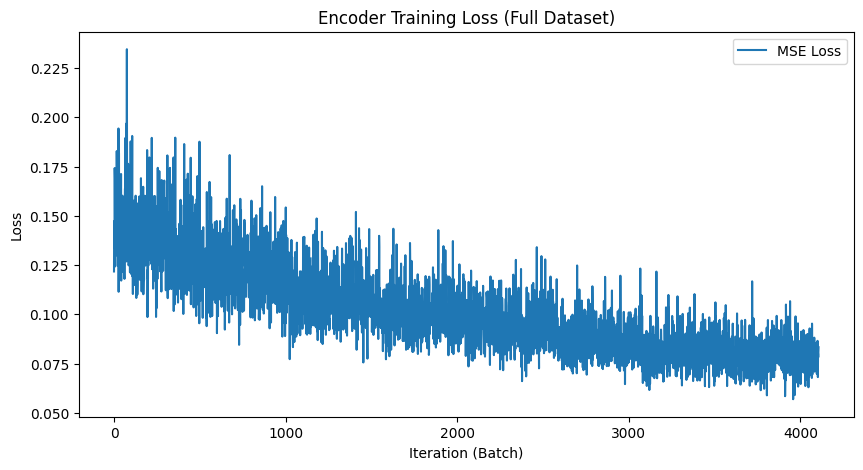

Full dataset encoder saved to models/resnet_encoder_full.pth


In [18]:
print("Training on full dataset complete!")

# Plot the training loss for the full dataset over iterations
plt.figure(figsize=(10, 5))
plt.plot(full_dataset_losses, label="MSE Loss")
plt.xlabel("Iteration (Batch)")
plt.ylabel("Loss")
plt.title("Encoder Training Loss (Full Dataset)")
plt.legend()
plt.show()

# Save the robustly fine-tuned encoder
torch.save(encoder.state_dict(), "models/resnet_encoder_full.pth")
print("Full dataset encoder saved to models/resnet_encoder_full.pth")

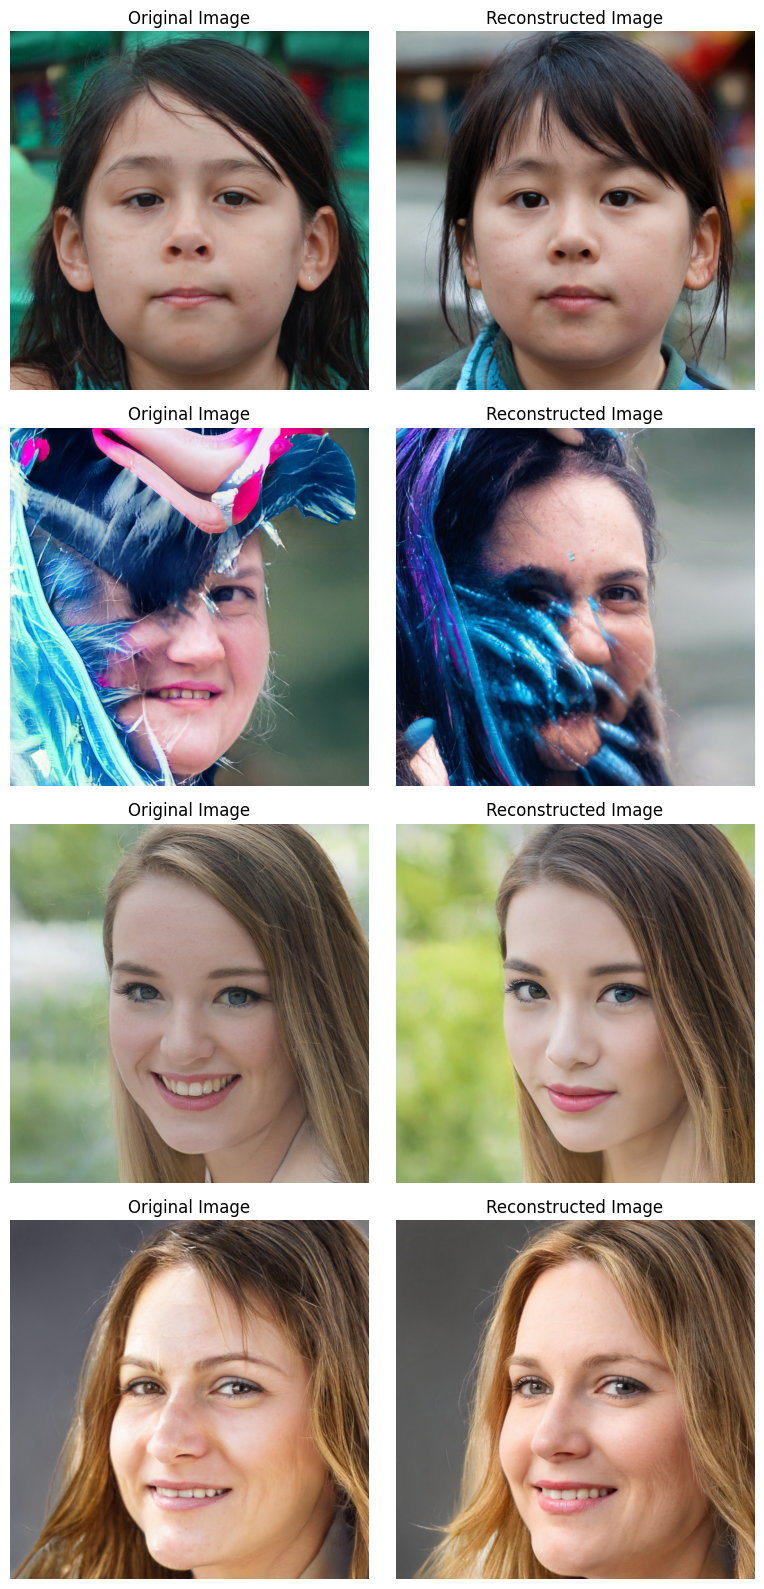

In [30]:
# Test the encoder on a few new images generated by the StyleGAN2 generator

# Generate a few new samples
test_batch_size = 4
with torch.no_grad():
    z_test = torch.randn([test_batch_size, G.z_dim], device=device)
    w_test = G.mapping(z_test, None)
    images_test = G.synthesis(w_test, noise_mode='const')
    
    # Images are in [-1, 1], move to [0, 255] and convert to uint8
    images_test = (images_test + 1) * (255 / 2.0)
    images_test = images_test.clamp(0, 255).to(torch.uint8).cpu().numpy()

# estimate W vectors using the encoder
# then generate images from the predicted W vectors using the generator
# draw the original and reconstructed images side by side for comparison
encoder.eval()
with torch.no_grad():
    # Preprocess test images for the encoder
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224), antialias=True),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Convert test images to PIL format and preprocess
    test_images_pil = [Image.fromarray(img.transpose(1, 2, 0)) for img in images_test]
    test_images_tensor = torch.stack([preprocess(img) for img in test_images_pil]).to(device)
    
    # Predict W vectors using the encoder
    predicted_w = encoder(test_images_tensor) # shape: (test_batch_size, num_ws, w_dim)
    
    # Generate images from the predicted W vectors using the generator
    reconstructed_images = G.synthesis(predicted_w, noise_mode='const')
    
    # Move reconstructed images to CPU and convert to uint8 for visualization
    reconstructed_images = (reconstructed_images + 1) * (255 / 2.0)
    reconstructed_images = reconstructed_images.clamp(0, 255).to(torch.uint8).cpu().numpy()
# Visualize original and reconstructed images side by side
fig, axes = plt.subplots(test_batch_size, 2, figsize=(8, 4 * test_batch_size))
for i in range(test_batch_size):
    # Original image
    axes[i, 0].imshow(images_test[i].transpose(1, 2, 0))
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')
    
    # Reconstructed image
    axes[i, 1].imshow(reconstructed_images[i].transpose(1, 2, 0))
    axes[i, 1].set_title("Reconstructed Image")
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

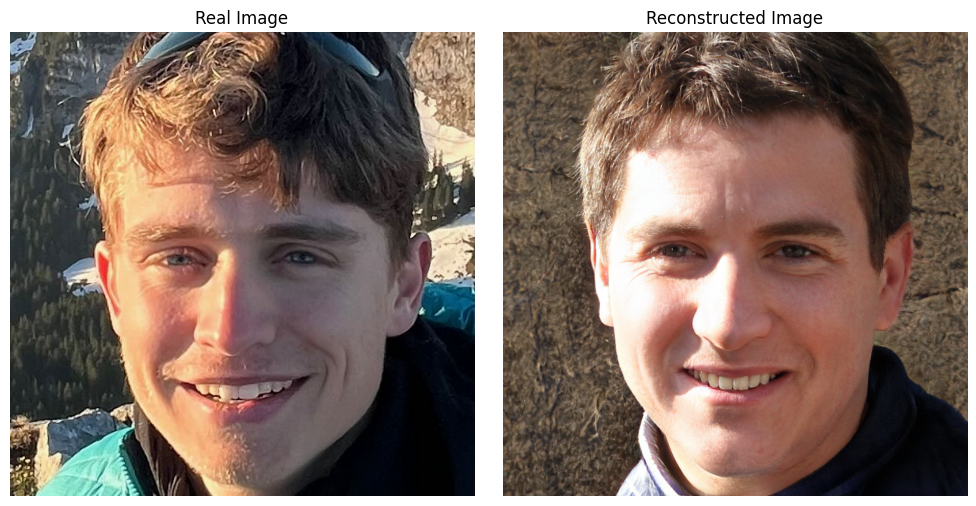

In [29]:
# Try reconstructing a real image located in the "real_images" directory using the encoder and generator
real_image_path = "real_images/IMG_9161.jpeg"  # Update this path to your real image
real_image = Image.open(real_image_path).convert("RGB")
# Preprocess the real image for the encoder
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
real_image_tensor = preprocess(real_image).unsqueeze(0).to(device)  # Add batch dimension
# Predict W vector using the encoder
encoder.eval()
with torch.no_grad():
    predicted_w_real = encoder(real_image_tensor)  # shape: (1, num_ws, w_dim)
    # Generate image from the predicted W vector using the generator
    reconstructed_real_image = G.synthesis(predicted_w_real, noise_mode='const')
    # Move reconstructed image to CPU and convert to uint8 for visualization
    reconstructed_real_image = (reconstructed_real_image + 1) * (255 / 2.0)
    reconstructed_real_image = reconstructed_real_image.clamp(0, 255).to(torch.uint8).cpu().numpy()[0].transpose(1, 2, 0)
# Visualize the real image and its reconstruction side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Real image
axes[0].imshow(real_image)
axes[0].set_title("Real Image")
axes[0].axis('off')
# Reconstructed image
axes[1].imshow(reconstructed_real_image)
axes[1].set_title("Reconstructed Image")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# With only few images and a small number of epochs :

In [2]:
encoder = ResNetEncoder(G.mapping.num_ws, G.mapping.w_dim).to(device)

NameError: name 'ResNetEncoder' is not defined

In [5]:
def generate_training_batch(G, batch_size, device):
    """
    Dynamically generates a batch of images and their corresponding W vectors.
    Preprocesses the images directly on the GPU so they are ready for ResNet.
    """
    with torch.no_grad():
        # 1. Sample Z from Gaussian
        z = torch.randn([batch_size, G.z_dim], device=device)
        
        # 2. Map Z to W
        # G.mapping outputs shape (batch_size, num_ws, w_dim)
        # where the w vector is duplicated num_ws times (e.g., 18x512 for 1024x1024 models)
        w = G.mapping(z, None)
        
        # 3. Synthesize images from W
        images = G.synthesis(w) # range is approx [-1, 1]
        
        # 4. Preprocess for ResNet
        # Scale to [0, 1]
        images = (images + 1.0) / 2.0
        images = torch.clamp(images, 0, 1)
        
        # Resize to 224x224 (default ResNet-18 input size)
        # Using bilinear instead of area to avoid AdaptiveAvgPool MPS exceptions
        images = nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
        
        # Normalize using ImageNet mean and std
        mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
        images = (images - mean) / std
        
    return images, w

In [ ]:
# Training Hyperparameters
batch_size = 16    # Adjust based on your GPU memory limits
iterations = 1000 # Number of batches to train on
learning_rate = 1e-2
decay_rate = 0.999

criterion = nn.MSELoss()
# Optimize only the parameters that require gradient (i.e. layer4 and the newly initialized fc layer)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, encoder.parameters()), lr=learning_rate)
scheduler = ExponentialLR(optimizer, gamma=decay_rate)

encoder.train()
G.eval()

print("Starting Fine-tuning...")
progress_bar = tqdm(range(iterations), desc="Training Encoder")
losses = []

for i in progress_bar:
    # 1. Generate data on the fly
    images, target_w = generate_training_batch(G, batch_size, device)
    
    # 2. Forward pass
    predicted_w = encoder(images)
    
    # 3. Compute loss
    loss = criterion(predicted_w, target_w)
    
    # 4. Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    # Track statistics
    losses.append(loss.item())
    progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

print("Training complete!")


Starting Fine-tuning...


Training Encoder:   0%|          | 0/1000 [00:00<?, ?it/s]

In [1]:
# Plot the training loss
plt.figure(figsize=(10, 5))
plt.plot(losses, label="MSE Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Encoder Training Loss")
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Save the fine-tuned encoder
torch.save(encoder.state_dict(), "models/resnet_encoder.pth")
print("Encoder saved to models/resnet_encoder.pth")

Encoder saved to models/resnet_encoder.pth


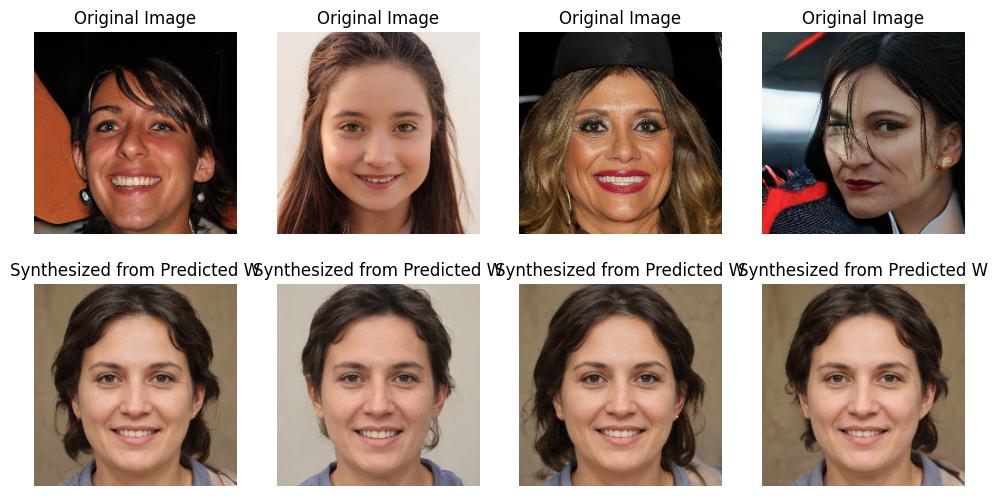

In [8]:
# test that the encoder can predict W vectors that generate images close to the originals
with torch.no_grad():
    # Generate a batch of data
    images, target_w = generate_training_batch(G, batch_size, device)
    
    # Get predicted W from the encoder
    predicted_w = encoder(images)
    
    # Synthesize images from the predicted W
    synthesized_images = G.synthesis(predicted_w)
    
    # Scale synthesized images to [0, 1] for visualization
    synthesized_images = (synthesized_images + 1.0) / 2.0
    synthesized_images = torch.clamp(synthesized_images, 0, 1)
    
    # Also scale original images for visualization
    original_images = (images * torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)) + torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    original_images = torch.clamp(original_images, 0, 1)

    # display a few examples
    num_examples = min(4, batch_size)
    plt.figure(figsize=(12, 6))
    for i in range(num_examples):
        # Original image
        plt.subplot(2, num_examples, i + 1)
        plt.imshow(original_images[i].cpu().permute(1, 2, 0))
        plt.title("Original Image")
        plt.axis('off')
        
        # Synthesized image from predicted W
        plt.subplot(2, num_examples, num_examples + i + 1)
        plt.imshow(synthesized_images[i].cpu().permute(1, 2, 0))
        plt.title("Synthesized from Predicted W")
        plt.axis('off')
    plt.show()